# Exploration de la base de donnée

In [298]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

### Analyse initiale : 

In [299]:
df = pd.read_csv("../data/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.000,PERSONAL,D,35000,16.020,1,0.590,Y,3
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4


| Variable | Description | Exemple |
|-----------|--------------|----------|
| **person_age** | Âge de la personne. | 22 |
| **person_income** | Revenu annuel de la personne (en dollars). | 59 000 |
| **person_home_ownership** | Statut de logement : **RENT** (locataire), **OWN** (propriétaire sans crédit), **MORTGAGE** (propriétaire avec prêt immobilier). | RENT |
| **person_emp_length** | Ancienneté professionnelle (en années). | 4.0 |
| **loan_intent** | Motif du prêt (ex. : PERSONAL, EDUCATION, MEDICAL, etc.). | PERSONAL |
| **loan_grade** | Niveau de risque du prêt (A = très bon, F = très risqué). | D |
| **loan_amnt** | Montant du prêt demandé (en dollars). | 35 000 |
| **loan_int_rate** | Taux d’intérêt du prêt (en %). | 16.02 |
| **loan_status** | Statut du remboursement : **1** = défaut de paiement, **0** = prêt remboursé. | 1 |
| **loan_percent_income** | Part du revenu annuel consacrée au remboursement du prêt (ratio). | 0.59 |
| **cb_person_default_on_file** | A-t-elle déjà eu un incident de crédit ? : **Y** = oui, **N** = non. | Y |
| **cb_person_cred_hist_length** |depuis combien d’années elle a des crédits enregistrés auprès d’une institution financière. | 3 |


In [300]:
print(f"- Le nombre de colonnes est de : {df.shape[0]}\n- Le nombre de lignes est de : {df.shape[1]}")

- Le nombre de colonnes est de : 32581
- Le nombre de lignes est de : 12


In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [302]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000,32581.000,31686.000,32581.000,29465.000,32581.000,32581.000,32581.000
mean,27.735,66074.848,4.790,9589.371,11.012,0.218,0.170,5.804
std,6.348,61983.119,4.143,6322.087,3.240,0.413,0.107,4.055
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000
25%,23.000,38500.000,2.000,5000.000,7.900,0.000,0.090,3.000
50%,26.000,55000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,79200.000,7.000,12200.000,13.470,0.000,0.230,8.000
max,144.000,6000000.000,123.000,35000.000,23.220,1.000,0.830,30.000


**Suppression des premieres anomalies visible:**

Un age max de 144 ans impossible

In [303]:
df["person_age"].value_counts().sort_index().tail(10)

person_age
69     5
70     7
73     3
76     1
78     1
80     1
84     1
94     1
123    2
144    3
Name: count, dtype: int64

In [304]:
df = df[df["person_age"]<=100]

Anciennete professionelle avec un maximum bcp trop élevée

In [305]:
df["person_emp_length"].value_counts().sort_index().tail(10)

person_emp_length
26.000     6
27.000     5
28.000     3
29.000     1
30.000     2
31.000     4
34.000     1
38.000     1
41.000     1
123.000    2
Name: count, dtype: int64

In [306]:
import numpy as np
df = df[(df["person_emp_length"]<=41) | df["person_emp_length"].isna() ]

Le revenu annuelle de la personne c'est possible mais valeur extreme donc preferable de supp

{'whiskers': [<matplotlib.lines.Line2D at 0x209305bfbf0>,
 'caps': [<matplotlib.lines.Line2D at 0x209305bd5b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x209305be360>],
 'medians': [<matplotlib.lines.Line2D at 0x20949203c50>],
 'fliers': [<matplotlib.lines.Line2D at 0x209492039b0>],
 'means': []}

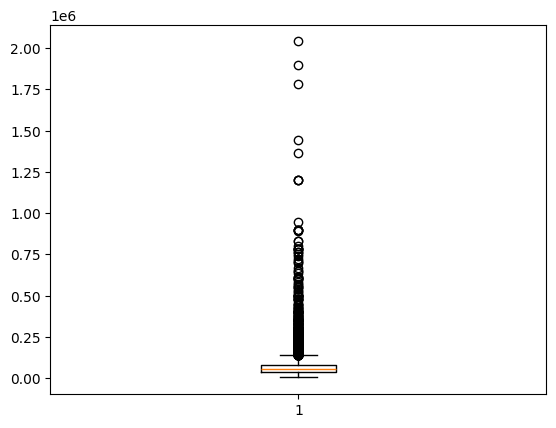

In [307]:
plt.boxplot(df["person_income"])

In [308]:
# Q1 = df["person_income"].quantile(0.25)
# Q3 = df["person_income"].quantile(0.75)

# IQR = Q3-Q1

# df = df[(df["person_income"] >= Q1 - 1.5 * IQR) & (df["person_income"] <= Q3 + 1.5 * IQR)]

{'whiskers': [<matplotlib.lines.Line2D at 0x20950512990>,
 'caps': [<matplotlib.lines.Line2D at 0x20950512390>,
 'boxes': [<matplotlib.lines.Line2D at 0x20950512c60>],
 'medians': [<matplotlib.lines.Line2D at 0x20949202c00>],
 'fliers': [<matplotlib.lines.Line2D at 0x209505128a0>],
 'means': []}

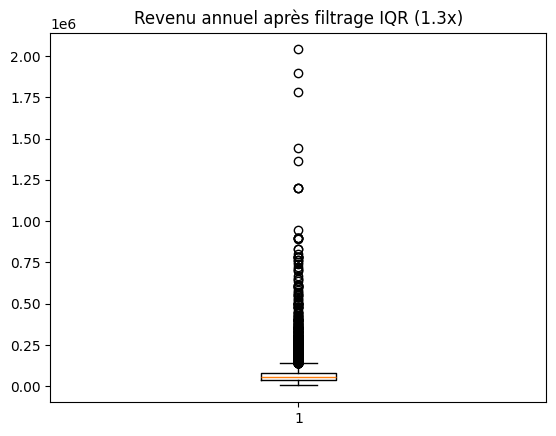

In [309]:
plt.title("Revenu annuel après filtrage IQR (1.3x)")
plt.boxplot(df["person_income"])

### Analyse des valeurs manquantes : 

In [310]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3115
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Trop de valeurs manquantes pour loan_status on va essayer de faire une imputation par variable corrélée (cf cours ML APP)

### On regarde si y a des doublons : 

In [311]:
print(f"Le nombre de doublons est de : {df.duplicated().sum()}")

Le nombre de doublons est de : 165


In [312]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15944,21,8088,RENT,NaN,MEDICAL,C,1200,15.230,0,0.150,Y,2
16835,21,8088,RENT,NaN,MEDICAL,C,1200,15.230,0,0.150,Y,2
2431,21,15600,RENT,0.000,MEDICAL,A,2800,7.400,1,0.180,N,4
17758,21,15600,RENT,0.000,MEDICAL,A,2800,7.400,1,0.180,N,4
2498,21,18000,RENT,0.000,DEBTCONSOLIDATION,A,3000,7.900,1,0.170,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.000,HOMEIMPROVEMENT,A,2500,5.420,0,0.060,N,12
29484,43,11340,RENT,4.000,EDUCATION,C,1950,NaN,1,0.170,N,11
32279,43,11340,RENT,4.000,EDUCATION,C,1950,NaN,1,0.170,N,11
31676,49,120000,MORTGAGE,12.000,MEDICAL,B,12000,10.990,0,0.100,N,12


In [313]:
df = df.drop_duplicates()

In [314]:
print(f"Le nombre de doublons est de : {df.duplicated().sum()}")

Le nombre de doublons est de : 0


In [315]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32409.000,32409.000,31522.000,32409.000,29315.000,32409.000,32409.000,32409.000
mean,27.731,65894.277,4.783,9592.487,11.017,0.219,0.170,5.811
std,6.210,52517.870,4.037,6320.885,3.242,0.413,0.107,4.058
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000
25%,23.000,38500.000,2.000,5000.000,7.900,0.000,0.090,3.000
50%,26.000,55000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,79200.000,7.000,12250.000,13.470,0.000,0.230,8.000
max,94.000,2039784.000,41.000,35000.000,23.220,1.000,0.830,30.000


Vérifions si y a des gens quiont taff + que ce qu'ils ont vécus

In [316]:
(df["person_age"] < df["person_emp_length"]).sum()

np.int64(0)

### Enregistrons la base au format CSV

In [317]:
df.to_csv(path_or_buf = "../data/output/df_credit_clear.csv",
          sep = ",")

In [318]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')